In [3]:
import pandas as pd

# Creating dataset manually (20 rows)
data = {
    "Study_Hours": [2,3,4,5,6,1,7,8,2,9,4,5,6,3,7,8,2,4,6,9],
    "Attendance": [60,65,70,75,80,50,85,90,55,95,68,72,78,66,88,92,58,74,82,97],
    "Previous_Score": [50,55,60,65,70,45,75,80,48,85,62,67,72,58,77,83,52,64,74,90],
    "Final_Score": [52,58,63,68,75,47,80,85,50,90,65,70,78,60,82,88,55,69,79,92]
}

df = pd.DataFrame(data)
df

,Study_Hours,Attendance,Previous_Score,Final_Score
0,2,60,50,52
1,3,65,55,58
2,4,70,60,63
3,5,75,65,68
4,6,80,70,75
5,1,50,45,47
6,7,85,75,80
7,8,90,80,85
8,2,55,48,50
9,9,95,85,90


In [4]:
# First 5 rows
print(df.head())

# Last 5 rows
print(df.tail())

# Shape
print("Shape:", df.shape)

# Data types
print(df.dtypes)

# Missing values
print(df.isnull().sum())

   Study_Hours  Attendance  Previous_Score  Final_Score
0            2          60              50           52
1            3          65              55           58
2            4          70              60           63
3            5          75              65           68
4            6          80              70           75
    Study_Hours  Attendance  Previous_Score  Final_Score
15            8          92              83           88
16            2          58              52           55
17            4          74              64           69
18            6          82              74           79
19            9          97              90           92
Shape: (20, 4)
Study_Hours       int64
Attendance        int64
Previous_Score    int64
Final_Score       int64
dtype: object
Study_Hours       0
Attendance        0
Previous_Score    0
Final_Score       0
dtype: int64


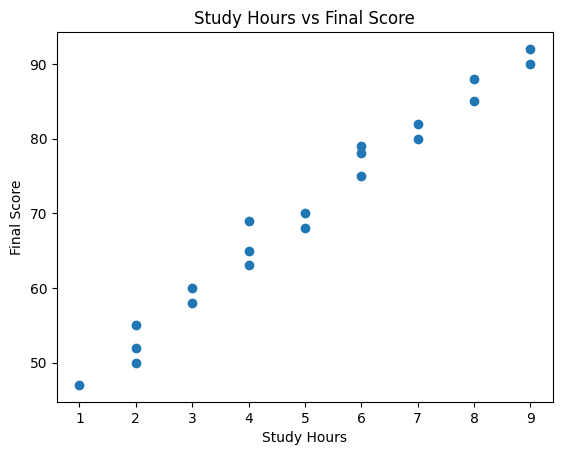

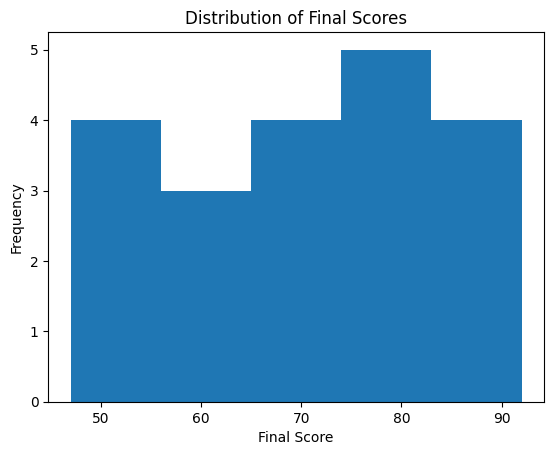

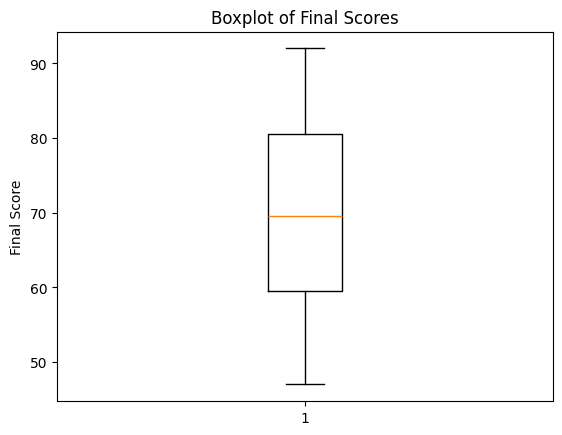

In [5]:
import matplotlib.pyplot as plt

# Scatter Plot
plt.scatter(df["Study_Hours"], df["Final_Score"])
plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.show()

# Histogram
plt.hist(df["Final_Score"], bins=5)
plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.boxplot(df["Final_Score"])
plt.title("Boxplot of Final Scores")
plt.ylabel("Final Score")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[["Study_Hours", "Attendance", "Previous_Score"]]
y = df["Final_Score"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.904898374659453
R2 Score: 0.99338230479365


In [7]:
X2 = df[["Study_Hours", "Previous_Score"]]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("MAE (without Attendance):", mean_absolute_error(y_test2, y_pred2))
print("R2 (without Attendance):", r2_score(y_test2, y_pred2))

MAE (without Attendance): 0.8846822541966368
R2 (without Attendance): 0.9922888370344506


In [8]:
df["Prep_Index"] = df["Study_Hours"] * df["Attendance"]

X3 = df[["Study_Hours", "Attendance", "Previous_Score", "Prep_Index"]]

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

print("MAE (with new feature):", mean_absolute_error(y_test3, y_pred3))
print("R2 (with new feature):", r2_score(y_test3, y_pred3))

MAE (with new feature): 0.8525279480731704
R2 (with new feature): 0.9933549000893414


In [9]:
# Training on full dataset (No split)
model_full = LinearRegression()
model_full.fit(X, y)

y_full_pred = model_full.predict(X)

print("MAE (Full Data):", mean_absolute_error(y, y_full_pred))
print("R2 (Full Data):", r2_score(y, y_full_pred))

MAE (Full Data): 0.741039052676815
R2 (Full Data): 0.9942380811559735
